
# Direction T: External new-drug proof with BV-BRC genome features

> Direction S đã tìm được thuốc mới external cho *Salmonella* như **tetracycline (TET)**, **ciprofloxacin (CIP)**, **streptomycin (STR)**.  
> Direction T thử lấy **genome feature annotations** từ BV-BRC cho các genome_id của thuốc mới, tạo feature matrix, rồi train/test model.

## Mục tiêu

1. Lấy dữ liệu AMR external từ `BV-BRC/AMRMetadataReview_2021`.
2. Lọc *Salmonella*.
3. Chọn thuốc mới, mặc định **tetracycline**.
4. Lấy genome features từ BV-BRC API, không tải raw FASTA.
5. Tạo ma trận presence/absence từ gene/product/PGFam/PLFam.
6. Train/test model cho thuốc mới external.
7. Xuất bảng metric để proof rằng thuốc mới có thể được mô hình hóa bằng genome features external.


In [1]:

# =========================
# 0. Import + config
# =========================

import os
import re
import json
import time
import math
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

import requests

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

BASE_DIR = Path("/content/salmonella_direction_T_external_new_drug_model")
REPO_DIR = BASE_DIR / "AMRMetadataReview_2021"
OUTPUT_DIR = BASE_DIR / "outputs"
CACHE_DIR = BASE_DIR / "cache"

for d in [BASE_DIR, OUTPUT_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Thuốc mới external muốn proof. Khuyên bắt đầu với TET vì ít lệch lớp nhất.
TARGET_DRUG_CODE = "TET"
TARGET_ANTIBIOTIC_CONTAINS = "tetracycline"

# Để chạy nhanh. Tăng lên 500 hoặc 1000 nếu API ổn.
N_PER_CLASS = 200

# API fetching
API_BASE = "https://www.bv-brc.org/api"
FEATURE_FIELDS = [
    "genome_id",
    "patric_id",
    "feature_id",
    "feature_type",
    "gene",
    "product",
    "pgfam_id",
    "plfam_id",
]
GENOME_CHUNK_SIZE = 5
API_SLEEP = 0.15
API_LIMIT_PER_QUERY = 50000

# Modeling
TEST_SIZE = 0.2
VAL_SIZE = 0.25
RANDOM_SEED = 42
K_FEATURES_LIST = [50, 100, 200, 500]

print("HAS_XGB:", HAS_XGB)
print("BASE_DIR:", BASE_DIR)
print("TARGET_DRUG_CODE:", TARGET_DRUG_CODE)
print("N_PER_CLASS:", N_PER_CLASS)


HAS_XGB: True
BASE_DIR: /content/salmonella_direction_T_external_new_drug_model
TARGET_DRUG_CODE: TET
N_PER_CLASS: 200


In [2]:

# =========================
# 1. Clone AMR metadata repo
# =========================

if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/BV-BRC/AMRMetadataReview_2021.git "{REPO_DIR}"
else:
    print("Repo đã tồn tại:", REPO_DIR)

print("Tabular files:")
!find "{REPO_DIR}/tabular" -maxdepth 1 -type f | head -20


Cloning into '/content/salmonella_direction_T_external_new_drug_model/AMRMetadataReview_2021'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 102 (delta 23), reused 102 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 559.36 MiB | 14.75 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Updating files: 100% (95/95), done.
Tabular files:
/content/salmonella_direction_T_external_new_drug_model/AMRMetadataReview_2021/tabular/README.md
/content/salmonella_direction_T_external_new_drug_model/AMRMetadataReview_2021/tabular/amr.mic.filt.tab
/content/salmonella_direction_T_external_new_drug_model/AMRMetadataReview_2021/tabular/amr.sir.filt.tab
/content/salmonella_direction_T_external_new_drug_model/AMRMetadataReview_2021/tabular/AMR.tbl.v4


In [3]:

# =========================
# 2. Đọc AMR long table và lọc Salmonella
# =========================

tabular_dir = REPO_DIR / "tabular"
files = sorted([p for p in tabular_dir.glob("*") if p.is_file()])

def read_any_table(path):
    path = Path(path)
    df = pd.read_csv(path, sep="\t", low_memory=False)
    if df.shape[1] == 1:
        df = pd.read_csv(path, low_memory=False)
    return df

def norm_col(c):
    return re.sub(r"[^a-z0-9]+", "_", str(c).lower()).strip("_")

def find_col(df, keywords):
    for c in df.columns:
        nc = norm_col(c)
        if all(k in nc for k in keywords):
            return c
    return None

def find_col_any(df, list_of_keyword_lists):
    for kws in list_of_keyword_lists:
        c = find_col(df, kws)
        if c is not None:
            return c
    return None

def infer_columns(df):
    return {
        "genome_id": find_col_any(df, [["genome", "id"], ["genome_id"], ["genome"]]),
        # ưu tiên genome_name để lọc Salmonella
        "species": find_col_any(df, [["genome", "name"], ["genome_name"], ["organism", "name"], ["organism"], ["species"], ["taxon", "name"], ["taxon"]]),
        "antibiotic": find_col_any(df, [["antibiotic"], ["drug"], ["antimicrobial"]]),
        "phenotype": find_col_any(df, [["resistant", "phenotype"], ["phenotype"], ["sir"], ["resistance"]]),
    }

def parse_sir_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["r", "resistant", "resistance", "non-susceptible", "nonsusceptible"]:
        return "R"
    if s in ["s", "susceptible", "sensitive", "susceptibility"]:
        return "S"
    if s in ["i", "intermediate"]:
        return "I"
    if "resistant" in s and "suscept" not in s:
        return "R"
    if "suscept" in s or "sensitive" in s:
        return "S"
    if "intermediate" in s:
        return "I"
    return np.nan

def normalize_antibiotic_name(x):
    s = str(x).strip()
    s = re.sub(r":.*$", "", s)
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

ANTIBIOTIC_SYNONYMS = {
    "tetracycline": "TET",
    "ciprofloxacin": "CIP",
    "streptomycin": "STR",
    "nalidixic acid": "NAL",
    "gentamicin": "GEN",
    "kanamycin": "KAN",
    "ceftiofur": "CEF",
    "sulfisoxazole": "FIS",
    "trimethoprim sulphamethoxazole": "SXT",
    "trimethoprim-sulfamethoxazole": "SXT",
    "trimethoprim/sulfamethoxazole": "SXT",
}

def antibiotic_code(name):
    s = normalize_antibiotic_name(name).lower()
    if s in ANTIBIOTIC_SYNONYMS:
        return ANTIBIOTIC_SYNONYMS[s]
    for key, code in ANTIBIOTIC_SYNONYMS.items():
        if key in s:
            return code
    return re.sub(r"[^A-Za-z]", "", s).upper()[:3]

long_tables = []

for p in files:
    try:
        df = read_any_table(p)
        cols = infer_columns(df)

        if cols["genome_id"] and cols["antibiotic"] and cols["phenotype"]:
            tmp = df.copy()
            tmp["source_file"] = p.name
            tmp["genome_id"] = tmp[cols["genome_id"]].astype(str)
            tmp["species"] = tmp[cols["species"]].astype(str) if cols["species"] else np.nan
            tmp["antibiotic"] = tmp[cols["antibiotic"]].apply(normalize_antibiotic_name)
            tmp["phenotype"] = tmp[cols["phenotype"]].apply(parse_sir_value)
            long_tables.append(tmp[["source_file", "genome_id", "species", "antibiotic", "phenotype"]])
        elif df.shape[1] >= 3:
            tmp = df.copy()
            tmp_cols = list(tmp.columns)
            tmp = tmp.rename(columns={
                tmp_cols[0]: "genome_id",
                tmp_cols[1]: "antibiotic_raw",
                tmp_cols[2]: "phenotype_raw"
            })
            tmp["source_file"] = p.name
            tmp["species"] = np.nan
            tmp["antibiotic"] = tmp["antibiotic_raw"].apply(normalize_antibiotic_name)
            tmp["phenotype"] = tmp["phenotype_raw"].apply(parse_sir_value)
            long_tables.append(tmp[["source_file", "genome_id", "species", "antibiotic", "phenotype"]])
    except Exception as e:
        print("Skip", p.name, e)

amr_long = pd.concat(long_tables, ignore_index=True)
amr_long = amr_long.dropna(subset=["genome_id", "antibiotic", "phenotype"])
amr_long = amr_long[amr_long["phenotype"].isin(["S", "R"])].copy()
amr_long["drug_code"] = amr_long["antibiotic"].apply(antibiotic_code)

salm = amr_long[amr_long["species"].astype(str).str.contains("salmonella", case=False, na=False)].copy()

print("amr_long:", amr_long.shape)
print("Salmonella:", salm.shape)
display(salm.head())

salm.to_csv(OUTPUT_DIR / "salmonella_external_amr_long.csv", index=False)


Skip README.md Error tokenizing data. C error: Expected 1 fields in line 4, saw 3

amr_long: (348230, 6)
Salmonella: (45517, 6)


,source_file,genome_id,species,antibiotic,phenotype,drug_code
409915,AMR.tbl.v4,28901.13275,Salmonella enterica strain 0153D,amoxicillin clavulanic acid,S,AMO
409916,AMR.tbl.v4,28901.13275,Salmonella enterica strain 0153D,ampicillin,R,AMP
409917,AMR.tbl.v4,28901.13275,Salmonella enterica strain 0153D,azithromycin,S,AZI
409918,AMR.tbl.v4,28901.13275,Salmonella enterica strain 0153D,cefoxitin,S,CEF
409919,AMR.tbl.v4,28901.13275,Salmonella enterica strain 0153D,ceftiofur,S,CEF


In [4]:

# =========================
# 3. Chọn thuốc mới target
# =========================

drug_summary = (
    salm
    .groupby(["antibiotic", "drug_code", "phenotype"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["S", "R"]:
    if col not in drug_summary.columns:
        drug_summary[col] = 0

drug_summary["n_total_SR"] = drug_summary["S"] + drug_summary["R"]
drug_summary["resistant_rate"] = drug_summary["R"] / drug_summary["n_total_SR"].replace(0, np.nan)
drug_summary = drug_summary.sort_values("n_total_SR", ascending=False)

display(drug_summary.head(20))
drug_summary.to_csv(OUTPUT_DIR / "salmonella_external_drug_summary.csv", index=False)

target = salm[
    (salm["drug_code"] == TARGET_DRUG_CODE) |
    (salm["antibiotic"].str.contains(TARGET_ANTIBIOTIC_CONTAINS, case=False, na=False))
].copy()

# nếu có duplicate genome_id-drug do nhiều source, lấy phenotype đầu tiên sau sort
target = target.sort_values(["genome_id", "phenotype"]).drop_duplicates(subset=["genome_id"])

print("Target rows:", target.shape)
print(target["phenotype"].value_counts())
display(target.head())

if target["phenotype"].nunique() < 2:
    raise ValueError("Target drug không có đủ S/R. Hãy đổi TARGET_DRUG_CODE hoặc TARGET_ANTIBIOTIC_CONTAINS.")

target.to_csv(OUTPUT_DIR / f"target_{TARGET_DRUG_CODE}_phenotype.csv", index=False)


phenotype,antibiotic,drug_code,R,S,n_total_SR,resistant_rate
2,ampicillin,AMP,1530,2317,3847,0.397713
16,chloramphenicol,CHL,774,3042,3816,0.202830
17,ciprofloxacin,CIP,627,2735,3362,0.186496
43,trimethoprim sulphamethoxazole,SXT,375,2765,3140,0.119427
39,tetracycline,TET,1611,1358,2969,0.542607
28,nalidixic acid,NAL,260,2650,2910,0.089347
34,streptomycin,STR,1257,1650,2907,0.432405
14,ceftriaxone,CEF,413,2383,2796,0.147711
23,gentamicin,GEN,314,2358,2672,0.117515
10,cefoxitin,CEF,336,2070,2406,0.139651


Target rows: (2867, 6)
phenotype
R    1561
S    1306
Name: count, dtype: int64


,source_file,genome_id,species,antibiotic,phenotype,drug_code
437842,AMR.tbl.v4,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,tetracycline,R,TET
446029,AMR.tbl.v4,108619.1,Salmonella enterica subsp. enterica serovar Ne...,tetracycline,R,TET
446065,AMR.tbl.v4,108619.101,Salmonella enterica subsp. enterica serovar Ne...,tetracycline,R,TET
445356,AMR.tbl.v4,108619.14,Salmonella enterica subsp. enterica serovar Ne...,tetracycline,S,TET
445104,AMR.tbl.v4,108619.141,Salmonella enterica subsp. enterica serovar Ne...,tetracycline,S,TET


In [5]:

# =========================
# 4. Lấy subset cân bằng S/R để proof
# =========================

rng = np.random.default_rng(RANDOM_SEED)

S_df = target[target["phenotype"] == "S"].copy()
R_df = target[target["phenotype"] == "R"].copy()

n_each = min(N_PER_CLASS, len(S_df), len(R_df))
print("n_each:", n_each)

S_sample = S_df.sample(n=n_each, random_state=RANDOM_SEED)
R_sample = R_df.sample(n=n_each, random_state=RANDOM_SEED)

target_balanced = pd.concat([S_sample, R_sample], ignore_index=True)
target_balanced = target_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

target_balanced["y"] = (target_balanced["phenotype"] == "R").astype(int)

print(target_balanced.shape)
print(target_balanced["y"].value_counts())
display(target_balanced.head())

target_balanced.to_csv(OUTPUT_DIR / f"target_{TARGET_DRUG_CODE}_balanced_subset.csv", index=False)


n_each: 200
(400, 7)
y
1    200
0    200
Name: count, dtype: int64


,source_file,genome_id,species,antibiotic,phenotype,drug_code,y
0,AMR.tbl.v4,28901.8205,Salmonella enterica strain 2014AM-0070,tetracycline,R,TET,1
1,AMR.tbl.v4,611.6,Salmonella enterica subsp. enterica serovar He...,tetracycline,R,TET,1
2,AMR.tbl.v4,28901.8566,Salmonella enterica strain CVM N31407,tetracycline,S,TET,0
3,AMR.tbl.v4,108619.94,Salmonella enterica subsp. enterica serovar Ne...,tetracycline,R,TET,1
4,AMR.tbl.v4,149387.7,Salmonella enterica subsp. enterica serovar Br...,tetracycline,S,TET,0


In [6]:

# =========================
# 5. BV-BRC genome_feature API functions
# =========================

def clean_feature_token(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s == "" or s in ["nan", "none", "hypothetical protein"]:
        return None
    s = re.sub(r"[^a-z0-9_\-\.]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    if len(s) < 2:
        return None
    return s[:120]

def features_to_tokens(df):
    tokens = []
    for _, r in df.iterrows():
        vals = []
        for col, prefix in [
            ("pgfam_id", "pgfam"),
            ("plfam_id", "plfam"),
            ("gene", "gene"),
            ("product", "prod"),
        ]:
            if col in df.columns:
                tok = clean_feature_token(r.get(col))
                if tok:
                    vals.append(f"{prefix}:{tok}")
        # ưu tiên family/gene, nhưng vẫn giữ product nếu không có gì khác
        tokens.extend(vals)
    return sorted(set(tokens))

def query_bvbrc_api(url, params=None, timeout=60):
    r = requests.get(url, params=params, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:300]}")
    try:
        return r.json()
    except Exception:
        # BV-BRC đôi khi trả TSV nếu accept chưa đúng
        text = r.text
        return text

def fetch_features_for_genome_eq(genome_id):
    # Query 1 genome bằng RQL eq.
    select = ",".join(FEATURE_FIELDS)
    url = f"{API_BASE}/genome_feature/"
    # Dùng query string trực tiếp để tránh encoding rql bị sai
    full_url = f"{url}?eq(genome_id,{genome_id})&select({select})&limit({API_LIMIT_PER_QUERY})"
    headers = {"Accept": "application/json"}
    r = requests.get(full_url, headers=headers, timeout=90)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:300]}")
    return r.json()

def fetch_features_for_genome(genome_id):
    cache_file = CACHE_DIR / f"features_{str(genome_id).replace('.', '_')}.json"
    if cache_file.exists():
        with open(cache_file, "r", encoding="utf-8") as f:
            return json.load(f)

    data = fetch_features_for_genome_eq(genome_id)

    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(data, f)
    time.sleep(API_SLEEP)
    return data

def genome_features_to_token_list(genome_id):
    try:
        data = fetch_features_for_genome(genome_id)
        if isinstance(data, dict) and "response" in data and "docs" in data["response"]:
            rows = data["response"]["docs"]
        elif isinstance(data, list):
            rows = data
        else:
            rows = data if isinstance(data, list) else []
        df = pd.DataFrame(rows)
        if len(df) == 0:
            return []
        # chỉ giữ CDS nếu có feature_type
        if "feature_type" in df.columns:
            df = df[df["feature_type"].astype(str).str.lower().isin(["cds", "peg", "protein"])]
            if len(df) == 0:
                df = pd.DataFrame(rows)
        return features_to_tokens(df)
    except Exception as e:
        print("Feature fetch failed for", genome_id, ":", e)
        return []


In [7]:

# =========================
# 6. Fetch genome features cho target subset
# =========================

genome_ids = target_balanced["genome_id"].astype(str).tolist()

tokens_by_genome = {}
failed = []

for i, gid in enumerate(genome_ids, 1):
    if i % 20 == 0:
        print(f"Fetching {i}/{len(genome_ids)}...")
    toks = genome_features_to_token_list(gid)
    if len(toks) == 0:
        failed.append(gid)
    tokens_by_genome[gid] = toks

print("Done.")
print("Failed/empty:", len(failed), "of", len(genome_ids))

# Lưu cache dạng json tổng
with open(OUTPUT_DIR / f"target_{TARGET_DRUG_CODE}_tokens_by_genome.json", "w", encoding="utf-8") as f:
    json.dump(tokens_by_genome, f)

# Nếu quá nhiều genome không có feature, dừng sớm
empty_rate = len(failed) / max(len(genome_ids), 1)
print("empty_rate:", empty_rate)
if empty_rate > 0.5:
    print("CẢNH BÁO: hơn 50% genome không fetch được features. Có thể API đổi hoặc genome_id không khớp.")


Fetching 20/400...
Fetching 40/400...
Fetching 60/400...
Fetching 80/400...
Fetching 100/400...
Fetching 120/400...
Fetching 140/400...
Fetching 160/400...
Fetching 180/400...
Fetching 200/400...
Fetching 220/400...
Fetching 240/400...
Fetching 260/400...
Fetching 280/400...
Fetching 300/400...
Fetching 320/400...
Fetching 340/400...
Fetching 360/400...
Fetching 380/400...
Fetching 400/400...
Done.
Failed/empty: 24 of 400
empty_rate: 0.06


In [8]:

# =========================
# 7. Tạo feature matrix
# =========================

valid_rows = []
token_lists = []

for _, row in target_balanced.iterrows():
    gid = str(row["genome_id"])
    toks = tokens_by_genome.get(gid, [])
    if len(toks) == 0:
        continue
    valid_rows.append(row.to_dict())
    token_lists.append(toks)

model_df = pd.DataFrame(valid_rows)
y = model_df["y"].astype(int).values

print("Usable rows:", model_df.shape)
print("Class counts:", pd.Series(y).value_counts().to_dict())

mlb = MultiLabelBinarizer(sparse_output=False)
X_all = pd.DataFrame(
    mlb.fit_transform(token_lists),
    columns=mlb.classes_,
    index=model_df["genome_id"].astype(str).values
).astype(np.int8)

print("X_all:", X_all.shape)
display(X_all.iloc[:3, :5])

X_all.to_csv(OUTPUT_DIR / f"target_{TARGET_DRUG_CODE}_feature_matrix.csv")
model_df.to_csv(OUTPUT_DIR / f"target_{TARGET_DRUG_CODE}_model_rows.csv", index=False)


Usable rows: (376, 7)
Class counts: {0: 190, 1: 186}
X_all: (376, 54937)


,gene:aac,gene:aac_3,gene:aac_6,gene:aac_6_-ib,gene:aada
28901.8205,0,0,0,0,0
28901.8566,0,0,0,0,0
108619.94,0,0,0,0,0


In [9]:

# =========================
# 8. Train/val/test split
# =========================

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED + 1000,
    stratify=y_trainval
)

print("Train:", X_train.shape, pd.Series(y_train).value_counts().to_dict())
print("Val:", X_val.shape, pd.Series(y_val).value_counts().to_dict())
print("Test:", X_test.shape, pd.Series(y_test).value_counts().to_dict())


Train: (225, 54937) {0: 114, 1: 111}
Val: (75, 54937) {0: 38, 1: 37}
Test: (76, 54937) {1: 38, 0: 38}


In [10]:

# =========================
# 9. Feature selection + model evaluation
# =========================

def safe_scores(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

def choose_threshold(y_val, prob_val):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_score = 0.5, -1
    for t in thresholds:
        pred = (prob_val >= t).astype(int)
        sc = f1_score(y_val, pred, zero_division=0)
        if sc > best_score:
            best_score = sc
            best_t = t
    return float(best_t), float(best_score)

def select_chi2_topk_external(X_train, y_train, k):
    k = min(k, X_train.shape[1])
    scores, _ = chi2(X_train.clip(lower=0), y_train)
    s = pd.Series(scores, index=X_train.columns).replace([np.inf, -np.inf], np.nan).fillna(0)
    return list(s.sort_values(ascending=False).head(k).index)

def make_model(model_name):
    if model_name == "LR_balanced":
        return LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_SEED)
    if model_name == "RF_balanced":
        return RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    if model_name == "XGB_weighted":
        pos = max(int(np.sum(y_train)), 1)
        neg = max(int(len(y_train) - np.sum(y_train)), 1)
        return xgb.XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            scale_pos_weight=neg / pos,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    raise ValueError(model_name)

model_names = ["LR_balanced", "RF_balanced"]
if HAS_XGB:
    model_names.append("XGB_weighted")

rows = []
top_feature_records = []

for k in K_FEATURES_LIST:
    selected = select_chi2_topk_external(X_train, y_train, k=k)

    # record selected features
    for rank, feat in enumerate(selected[:50], 1):
        top_feature_records.append({"k": k, "rank": rank, "feature": feat})

    Xtr = X_train[selected]
    Xva = X_val[selected]
    Xte = X_test[selected]

    for model_name in model_names:
        model = make_model(model_name)
        model.fit(Xtr, y_train)

        pv = model.predict_proba(Xva)[:, 1]
        pt = model.predict_proba(Xte)[:, 1]

        threshold, val_f1 = choose_threshold(y_val, pv)
        pred = (pt >= threshold).astype(int)

        sc = safe_scores(y_test, pred, pt)
        rows.append({
            "target_drug_code": TARGET_DRUG_CODE,
            "target_antibiotic_contains": TARGET_ANTIBIOTIC_CONTAINS,
            "n_per_class_requested": N_PER_CLASS,
            "n_usable": len(y),
            "k_features": k,
            "model": model_name,
            "threshold": threshold,
            "val_f1_for_threshold": val_f1,
            **sc
        })

results_df = pd.DataFrame(rows)
top_features_df = pd.DataFrame(top_feature_records)

display(results_df.sort_values(["f1", "balanced_accuracy", "auprc"], ascending=False))
display(top_features_df.head(30))

results_df.to_csv(OUTPUT_DIR / f"external_new_drug_{TARGET_DRUG_CODE}_model_results.csv", index=False)
top_features_df.to_csv(OUTPUT_DIR / f"external_new_drug_{TARGET_DRUG_CODE}_top_features.csv", index=False)


,target_drug_code,target_antibiotic_contains,n_per_class_requested,n_usable,k_features,model,threshold,val_f1_for_threshold,accuracy,balanced_accuracy,precision,recall,f1,auroc,auprc
9,TET,tetracycline,200,376,500,LR_balanced,0.43,0.958904,0.973684,0.973684,0.973684,0.973684,0.973684,0.984765,0.988341
4,TET,tetracycline,200,376,100,RF_balanced,0.27,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.984765,0.987769
5,TET,tetracycline,200,376,100,XGB_weighted,0.33,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.985457,0.987769
0,TET,tetracycline,200,376,50,LR_balanced,0.28,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.984765,0.987383
1,TET,tetracycline,200,376,50,RF_balanced,0.25,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.984765,0.987383
2,TET,tetracycline,200,376,50,XGB_weighted,0.31,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.984765,0.987383
8,TET,tetracycline,200,376,200,XGB_weighted,0.32,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.984072,0.987277
3,TET,tetracycline,200,376,100,LR_balanced,0.31,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.984072,0.987076
6,TET,tetracycline,200,376,200,LR_balanced,0.32,0.972973,0.960526,0.960526,0.948718,0.973684,0.961039,0.983033,0.987076
10,TET,tetracycline,200,376,500,RF_balanced,0.35,0.972973,0.947368,0.947368,0.925000,0.973684,0.948718,0.982687,0.988865


,k,rank,feature
0,50,1,pgfam:pgf_03416711
1,50,2,prod:tetracycline_resistance_regulatory_protei...
2,50,3,plfam:plf_590_00006384
3,50,4,prod:tetracycline_resistance_mfs_efflux_pump_t...
4,50,5,pgfam:pgf_03114542
5,50,6,plfam:plf_590_00006425
6,50,7,prod:dihydropteroate_synthase_type-2_ec_2.5.1....
7,50,8,pgfam:pgf_00423408
8,50,9,pgfam:pgf_02752571
9,50,10,prod:periplasmic_mercury_2_binding_protein_merp


In [11]:

# =========================
# 10. Kết luận tự động
# =========================

best = results_df.sort_values(["f1", "balanced_accuracy", "auprc"], ascending=False).iloc[0]

lines = []
lines.append("# Direction T — Auto conclusion")
lines.append("")
lines.append("## 1. Mục tiêu")
lines.append(f"Direction T thử model external cho thuốc mới {TARGET_DRUG_CODE} ({TARGET_ANTIBIOTIC_CONTAINS}) bằng dữ liệu BV-BRC/PATRIC Salmonella.")
lines.append("")
lines.append("## 2. Dữ liệu")
lines.append(f"- Target rows ban đầu: {len(target)}.")
lines.append(f"- Balanced subset yêu cầu: {N_PER_CLASS} S và {N_PER_CLASS} R nếu đủ.")
lines.append(f"- Usable rows sau khi fetch genome features: {len(y)}.")
lines.append(f"- Số feature annotation ban đầu: {X_all.shape[1]}.")
lines.append("")
lines.append("## 3. Best model")
lines.append(
    f"- Best = {best['model']} với k={int(best['k_features'])} features; "
    f"F1={best['f1']:.3f}, balanced accuracy={best['balanced_accuracy']:.3f}, "
    f"AUPRC={best['auprc']:.3f}, AUROC={best['auroc']:.3f}."
)
lines.append("")
lines.append("## 4. Diễn giải")
lines.append("- Nếu kết quả tốt, đây là proof rằng thuốc mới ngoài bộ 5 thuốc gốc có thể được mô hình hóa bằng genome annotations external.")
lines.append("- Nếu kết quả thấp, có thể do feature lấy từ API chưa đủ, số genome ít, hoặc thuốc mới cần feature chuyên biệt hơn.")
lines.append("- Notebook không tải raw FASTQ; feature lấy từ annotation BV-BRC nên phù hợp làm proof nhẹ.")

conclusion = "\n".join(lines)
print(conclusion)

with open(OUTPUT_DIR / f"AUTO_CONCLUSION_DIRECTION_T_{TARGET_DRUG_CODE}.md", "w", encoding="utf-8") as f:
    f.write(conclusion)


# Direction T — Auto conclusion

## 1. Mục tiêu
Direction T thử model external cho thuốc mới TET (tetracycline) bằng dữ liệu BV-BRC/PATRIC Salmonella.

## 2. Dữ liệu
- Target rows ban đầu: 2867.
- Balanced subset yêu cầu: 200 S và 200 R nếu đủ.
- Usable rows sau khi fetch genome features: 376.
- Số feature annotation ban đầu: 54937.

## 3. Best model
- Best = LR_balanced với k=500 features; F1=0.974, balanced accuracy=0.974, AUPRC=0.988, AUROC=0.985.

## 4. Diễn giải
- Nếu kết quả tốt, đây là proof rằng thuốc mới ngoài bộ 5 thuốc gốc có thể được mô hình hóa bằng genome annotations external.
- Nếu kết quả thấp, có thể do feature lấy từ API chưa đủ, số genome ít, hoặc thuốc mới cần feature chuyên biệt hơn.
- Notebook không tải raw FASTQ; feature lấy từ annotation BV-BRC nên phù hợp làm proof nhẹ.


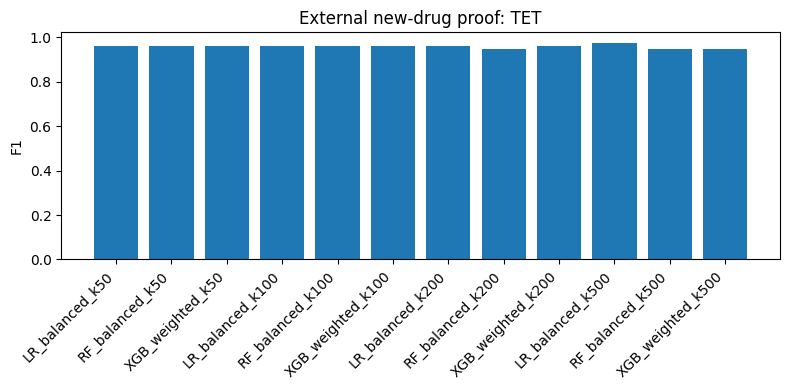

Output dir: /content/salmonella_direction_T_external_new_drug_model/outputs
Zip: /content/salmonella_direction_T_external_new_drug_model/salmonella_direction_T_TET_outputs.zip


In [12]:

# =========================
# 11. Visualization + zip
# =========================

plt.figure(figsize=(8, 4))
labels = results_df["model"] + "_k" + results_df["k_features"].astype(str)
plt.bar(labels, results_df["f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1")
plt.title(f"External new-drug proof: {TARGET_DRUG_CODE}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"external_new_drug_{TARGET_DRUG_CODE}_f1.png", dpi=200)
plt.show()

zip_path = BASE_DIR / f"salmonella_direction_T_{TARGET_DRUG_CODE}_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("Output dir:", OUTPUT_DIR)
print("Zip:", zip_path)

# Nếu muốn tải về:
# from google.colab import files
# files.download(str(zip_path))
